In [1]:
try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    %pip install -q git+https://github.com/ICSM/pgmuvi.git
    import pgmuvi

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 10.4 MB/s eta 0:00:00


In [3]:
# Core imports for the GP-fitting sections

import random
import numpy as np
import torch
import gpytorch

from pgmuvi.lightcurve import Lightcurve
from pgmuvi import synthetic
import pgmuvi.gps as gps

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DTYPE = torch.float64
DEVICE = torch.device("cpu")

## Gaussian-process fitting in `pgmuvi`

The central method for GP fitting in `pgmuvi` is `Lightcurve.fit()`. It accepts a `Lightcurve` object and fits one of several Gaussian-process models to the data.

At a high level, the workflow is:

1. construct a `Lightcurve`,
2. choose a GP model,
3. optionally provide period guesses or let the code initialise them from Lomb--Scargle,
4. optimise the model hyperparameters,
5. inspect the fitted kernel and interpret the implied power spectral density (PSD).

The same interface is used for both 1D and 2D light curves, but the available models differ depending on whether the data contain only a time axis or both time and wavelength.

## GP model families available in `pgmuvi`

`pgmuvi` provides several GP model families. They are not interchangeable: each encodes a different assumption about the temporal or multiwavelength structure of the variability.

### 1D models

These are intended for single-band light curves.

- **`'1D'`**: spectral-mixture GP  
  Flexible and often the most useful model when multiple periodic or quasi-periodic components may be present.  
  This is the main model for interpreting variability through the GP-derived PSD.

- **`'1DQuasiPeriodic'`**: quasi-periodic GP  
  Appropriate when one dominant repeating timescale is present, but the signal evolves gradually in amplitude or phase.

- **`'1DMatern'`**: Matérn GP  
  Appropriate for correlated stochastic variability without a strong periodic component.

- **`'1DPeriodicStochastic'`**: periodic + stochastic GP  
  Useful when a source shows both a repeating component and additional correlated noise or structured residual variability.

### 2D models

These are intended for light curves with both time and wavelength.

- **`'2D'`**: 2D spectral-mixture GP  
  A flexible model that can represent complex joint structure in time and wavelength.

- **`'2DSeparable'`**: separable time--wavelength GP  
  Assumes the covariance can be factorised into a temporal part and a wavelength part.

- **`'2DAchromatic'`**: achromatic GP  
  Appropriate when the temporal variability is shared across wavelengths.

- **`'2DWavelengthDependent'`**: wavelength-dependent GP  
  Appropriate when the temporal behaviour is correlated across wavelength but not identical in every band.

- **`'2DDustMean'`** and **`'2DPowerLawMean'`**: wavelength-dependent GPs with physically motivated mean functions  
  These are useful when the mean spectral behaviour itself carries physical information and should be modeled explicitly.

In this notebook, the main emphasis will be on **spectral-mixture models**, because they provide a natural route from the fitted kernel to a PSD and then to dominant periods.

In [4]:
# A compact reference table for the models that we will actually use in this notebook

MODEL_REFERENCE = {
    "1D": {
        "class": gps.SpectralMixtureGPModel,
        "use_case": "Flexible 1D periodic or multi-periodic variability",
    },
    "1DQuasiPeriodic": {
        "class": gps.QuasiPeriodicGPModel,
        "use_case": "One dominant evolving cycle",
    },
    "1DMatern": {
        "class": gps.MaternGPModel,
        "use_case": "Correlated stochastic variability",
    },
    "1DPeriodicStochastic": {
        "class": gps.PeriodicPlusStochasticGPModel,
        "use_case": "Periodic signal plus correlated stochastic structure",
    },
    "2D": {
        "class": gps.TwoDSpectralMixtureGPModel,
        "use_case": "Flexible joint time-wavelength structure",
    },
    "2DSeparable": {
        "class": gps.SeparableGPModel,
        "use_case": "Factorised time and wavelength covariance",
    },
    "2DAchromatic": {
        "class": gps.AchromaticGPModel,
        "use_case": "Same temporal behaviour across wavelength",
    },
    "2DWavelengthDependent": {
        "class": gps.WavelengthDependentGPModel,
        "use_case": "Smoothly varying temporal behaviour across wavelength",
    },
    "2DDustMean": {
        "class": gps.DustMeanGPModel,
        "use_case": "Wavelength-dependent variability with dust-like mean structure",
    },
    "2DPowerLawMean": {
        "class": gps.PowerLawMeanGPModel,
        "use_case": "Wavelength-dependent variability with power-law mean structure",
    },
}

for model_name, info in MODEL_REFERENCE.items():
    print(f"{model_name:20s} -> {info['class'].__name__:30s} | {info['use_case']}")

1D                   -> SpectralMixtureGPModel         | Flexible 1D periodic or multi-periodic variability
1DQuasiPeriodic      -> QuasiPeriodicGPModel           | One dominant evolving cycle
1DMatern             -> MaternGPModel                  | Correlated stochastic variability
1DPeriodicStochastic -> PeriodicPlusStochasticGPModel  | Periodic signal plus correlated stochastic structure
2D                   -> TwoDSpectralMixtureGPModel     | Flexible joint time-wavelength structure
2DSeparable          -> SeparableGPModel               | Factorised time and wavelength covariance
2DAchromatic         -> AchromaticGPModel              | Same temporal behaviour across wavelength
2DWavelengthDependent -> WavelengthDependentGPModel     | Smoothly varying temporal behaviour across wavelength
2DDustMean           -> DustMeanGPModel                | Wavelength-dependent variability with dust-like mean structure
2DPowerLawMean       -> PowerLawMeanGPModel            | Wavelength-dependent 

## A practical way to choose a GP model

There is no universally best kernel. The choice should follow the scientific question.

A reasonable starting point is:

- use **`'1D'`** for single-band light curves when the goal is to recover one or more characteristic periods from the GP PSD;
- use **`'1DQuasiPeriodic'`** when there is one clear cycle and a simpler model is preferred;
- use **`'1DMatern'`** when the variability is correlated but not obviously periodic;
- use **`'2D'`** when a fully flexible joint model in time and wavelength is desired;
- use **`'2DAchromatic'`** when the same temporal pattern is expected in all bands;
- use **`'2DWavelengthDependent'`** when nearby wavelengths should behave similarly, but not identically.

In the examples below, we will begin with spectral-mixture models because they connect directly to the PSD-based interpretation of the GP fit.

## Basic GP-fitting workflow in `pgmuvi`

The method used throughout this notebook is:

```python
lc.fit(
    model=...,
    training_iter=...,
    use_mls_init=True,
    use_best_band_init=False,
    num_mixtures=...,
)```

Some arguments that will matter later are:

`model`: selects the GP model family;
`training_iter`: number of optimisation iterations;
`num_mixtures`: number of spectral-mixture components when using spectral-mixture kernels;
`use_mls_init`: initialise spectral-mixture components from Lomb--Scargle peaks;
`use_best_band_init`: for multi-band data, use the best individual band to initialise the period guesses;
`periods`: manual period guesses, if desired.

For spectral-mixture models, `use_mls_init=True` is often a sensible default because it gives the optimiser a physically motivated starting point.

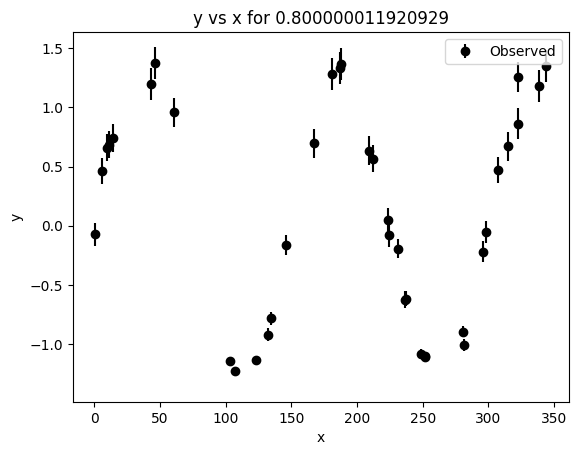

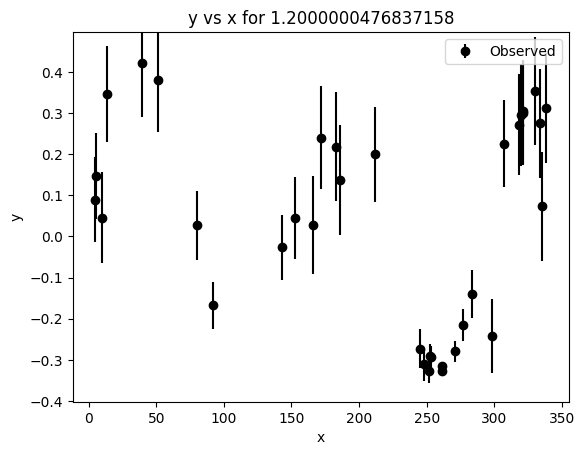

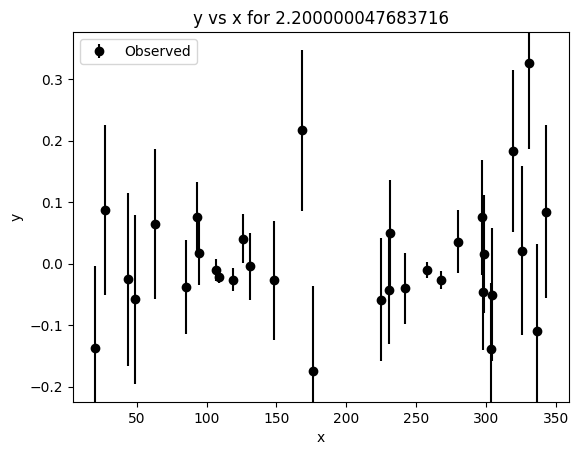

<class 'pgmuvi.lightcurve.Lightcurve'>
Number of data points: 106


In [5]:
# Minimal synthetic example using the actual keyword pattern from the tutorial notebook

lc_template = synthetic.make_chromatic_sinusoid_2d(
    period=150,
    t_span=150 * 2.3,
    n_per_band=(25, 40),
    wavelengths=[0.8, 1.2, 2.2],
    amplitude_law="extinction",
    seed=SEED,
)

lc_template.plot()
print(type(lc_template))
print("Number of data points:", lc_template.ydata.numel())

The example above is only meant to show the basic `Lightcurve.fit()` workflow on a synthetic light curve generated with the same configuration pattern used in the tutorial notebook.

Although this dataset is generated by a 2D synthetic generator, it is sufficient for demonstrating the fitting interface. The dedicated 1D and 2D examples below will use more appropriate datasets for scientific interpretation.